#L'objectif de ce laboratoire est de prédire le prix de vente d'une maison en fonction de ses caractéristiques.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version :", tf.__version__)

TensorFlow version : 2.19.0


#Charger l'ensemble de données

In [9]:
df = pd.read_csv('/content/sample_data/AmesHousing.csv')
print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (2930, 82)
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condi

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [8]:
print("\n statistical summary:")
print(df.describe())


 statistical summary:
            Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2440.000000    2930.000000   
mean   1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std     845.96247  1.887308e+08    42.638025     23.365335    7880.017759   
min       1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     733.25000  5.284770e+08    20.000000     58.000000    7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000    9436.500000   
75%    2197.75000  9.071811e+08    70.000000     80.000000   11555.250000   
max    2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   

       Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
count   2930.000000   2930.000000  2930.000000     2930.000000   2907.000000   
mean       6.094881      5.563140  1971.356314     1984.266553    101.896801   
std        1.411026      1.111537    30.245

#Traitement des valeurs manquantes : La première étape consiste à afficher les valeurs manquantes dans chaque colonne.

In [11]:
VM = pd.DataFrame({
    'Column'     : df.columns.values,
    'Nb missing' : df.isna().sum().values,
    '% missing'  : 100 * df.isna().sum().values / len(df),
})
# Keep only columns that actually have at least one missing value
VM = VM[VM['Nb missing'] > 0]
print("\nColumns with missing values (sorted by count):")
print(VM.sort_values(by='Nb missing', ascending=False).reset_index(drop=True))


Columns with missing values (sorted by count):
            Column  Nb missing  % missing
0          Pool QC        2917  99.556314
1     Misc Feature        2824  96.382253
2            Alley        2732  93.242321
3            Fence        2358  80.477816
4     Mas Vnr Type        1775  60.580205
5     Fireplace Qu        1422  48.532423
6     Lot Frontage         490  16.723549
7      Garage Qual         159   5.426621
8      Garage Cond         159   5.426621
9    Garage Yr Blt         159   5.426621
10   Garage Finish         159   5.426621
11     Garage Type         157   5.358362
12   Bsmt Exposure          83   2.832765
13  BsmtFin Type 2          81   2.764505
14       Bsmt Cond          80   2.730375
15       Bsmt Qual          80   2.730375
16  BsmtFin Type 1          80   2.730375
17    Mas Vnr Area          23   0.784983
18  Bsmt Full Bath           2   0.068259
19  Bsmt Half Bath           2   0.068259
20    BsmtFin SF 1           1   0.034130
21    BsmtFin SF 2          

Suppression des colonnes contenant principalement des valeurs manquantes

In [12]:
threshold = 40
cols_to_drop = VM[VM['% missing'] > threshold]['Column'].tolist()
df = df.drop(columns=cols_to_drop)
print(f"\n{len(cols_to_drop)} columns dropped (missing rate > {threshold}%):")
print(cols_to_drop)


6 columns dropped (missing rate > 40%):
['Alley', 'Mas Vnr Type', 'Fireplace Qu', 'Pool QC', 'Fence', 'Misc Feature']


Nous analysons les valeurs présentes dans chaque colonne pour déterminer la méthode d’imputation la plus adaptée (moyenne ou mode)

In [13]:
cols_with_mv = df.columns[df.isna().sum() > 0]
print("\nRemaining columns still having missing values:")
for col in cols_with_mv:
    print(f"  {col}  →  sample values: {df[col].unique()[:5]}")
    print('  ' + '-' * 40)


Remaining columns still having missing values:
  Lot Frontage  →  sample values: [141.  80.  81.  93.  74.]
  ----------------------------------------
  Mas Vnr Area  →  sample values: [112.   0. 108.  20. 603.]
  ----------------------------------------
  Bsmt Qual  →  sample values: ['TA' 'Gd' 'Ex' nan 'Fa']
  ----------------------------------------
  Bsmt Cond  →  sample values: ['Gd' 'TA' nan 'Po' 'Fa']
  ----------------------------------------
  Bsmt Exposure  →  sample values: ['Gd' 'No' 'Mn' 'Av' nan]
  ----------------------------------------
  BsmtFin Type 1  →  sample values: ['BLQ' 'Rec' 'ALQ' 'GLQ' 'Unf']
  ----------------------------------------
  BsmtFin SF 1  →  sample values: [ 639.  468.  923. 1065.  791.]
  ----------------------------------------
  BsmtFin Type 2  →  sample values: ['Unf' 'LwQ' 'BLQ' 'Rec' nan]
  ----------------------------------------
  BsmtFin SF 2  →  sample values: [   0.  144. 1120.  163.  168.]
  ----------------------------------------
  

Dans les colonnes numériques, les valeurs manquantes (NaN) sont remplacées par la moyenne de la colonne.

In [14]:
num_MV = ['Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
          'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath',
          'Bsmt Half Bath', 'Garage Yr Blt', 'Garage Cars', 'Garage Area']

for col in num_MV:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mean())
        print(f"  [NUM] '{col}' filled with mean: {df[col].mean():.2f}")

  [NUM] 'Lot Frontage' filled with mean: 69.22
  [NUM] 'Mas Vnr Area' filled with mean: 101.90
  [NUM] 'BsmtFin SF 1' filled with mean: 442.63
  [NUM] 'BsmtFin SF 2' filled with mean: 49.72
  [NUM] 'Bsmt Unf SF' filled with mean: 559.26
  [NUM] 'Total Bsmt SF' filled with mean: 1051.61
  [NUM] 'Bsmt Full Bath' filled with mean: 0.43
  [NUM] 'Bsmt Half Bath' filled with mean: 0.06
  [NUM] 'Garage Yr Blt' filled with mean: 1978.13
  [NUM] 'Garage Cars' filled with mean: 1.77
  [NUM] 'Garage Area' filled with mean: 472.82


In [15]:
cat_MV = [x for x in cols_with_mv if x not in num_MV]
for col in cat_MV:
    if col in df.columns:
        mode_val = df[col].mode().to_numpy()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"  [CAT] '{col}' filled with mode: '{mode_val}'")

# Final verification — this must print 0
print("\nTotal missing values remaining:", df.isna().sum().sum())

  [CAT] 'Bsmt Qual' filled with mode: 'TA'
  [CAT] 'Bsmt Cond' filled with mode: 'TA'
  [CAT] 'Bsmt Exposure' filled with mode: 'No'
  [CAT] 'BsmtFin Type 1' filled with mode: 'GLQ'
  [CAT] 'BsmtFin Type 2' filled with mode: 'Unf'
  [CAT] 'Electrical' filled with mode: 'SBrkr'
  [CAT] 'Garage Type' filled with mode: 'Attchd'
  [CAT] 'Garage Finish' filled with mode: 'Unf'
  [CAT] 'Garage Qual' filled with mode: 'TA'
  [CAT] 'Garage Cond' filled with mode: 'TA'

Total missing values remaining: 0


#Encodage des variables catégorielles

In [ ]:
df['MS SubClass'] = df['MS SubClass'].astype(str)


Nous sélectionnons uniquement 20 variables pertinentes au lieu des 82 disponibles, car l’encodage de toutes les colonnes générerait plus de 200 variables binaires, ce qui rendrait le modèle beaucoup plus lent à entraîner et augmenterait le risque de surapprentissage (overfitting)

In [ ]:
selected_features = [
    'MS SubClass',
    'MS Zoning',
    'Lot Frontage',
    'Lot Area',
    'Neighborhood',
    'Overall Qual',
    'Overall Cond',
    'Year Built',
    'Total Bsmt SF',
    '1st Flr SF',
    '2nd Flr SF',
    'Gr Liv Area',
    'Full Bath',
    'Half Bath',
    'Bedroom AbvGr',
    'Kitchen AbvGr',
    'TotRms AbvGrd',
    'Garage Area',
    'Pool Area',
    'SalePrice'
]
df = df[selected_features]

In [16]:
df = pd.get_dummies(df)
print("\nNumber of columns after One-Hot Encoding:", df.shape[1])


Number of columns after One-Hot Encoding: 282


#Train / Test Split

In [17]:
train = df.sample(frac=0.8, random_state=9)
test  = df.drop(train.index)   # test = everything NOT in train

In [18]:
# pop() removes the 'SalePrice' column from the DataFrame and returns it.
train_target = train.pop('SalePrice')
test_target  = test.pop('SalePrice')

In [19]:
print(f"\nTrain set : {train.shape[0]} rows, {train.shape[1]} feature columns")
print(f"Test set  : {test.shape[0]} rows,  {test.shape[1]} feature columns")
print(f"\nTrain SalePrice range: ${train_target.min():,.0f} – ${train_target.max():,.0f}")
print(f"Test  SalePrice range: ${test_target.min():,.0f}  – ${test_target.max():,.0f}")



Train set : 2344 rows, 281 feature columns
Test set  : 586 rows,  281 feature columns

Train SalePrice range: $12,789 – $755,000
Test  SalePrice range: $40,000  – $591,587


#Standardisation

In [20]:
for col in train.columns:
    col_mean = train[col].mean()
    col_std  = train[col].std()

    # Guard against division by zero for constant columns (all same value)
    if col_std == 0:
        col_std = 1e-20

    # Apply the SAME transformation to both sets
    train[col] = (train[col] - col_mean) / col_std
    test[col]  = (test[col]  - col_mean) / col_std

sample_col = train.columns[0]
print(f"\nAfter standardization (column: '{sample_col}'):")
print(f"  Train mean : {train[sample_col].mean():.6f} ")
print(f"  Train std  : {train[sample_col].std():.6f}  ")



After standardization (column: 'Order'):
  Train mean : 0.000000 
  Train std  : 1.000000  


#Construction du réseau de neurones

Nous utilisons keras.Sequential, qui permet d’empiler les couches de manière linéaire : les données passent de l’entrée à la sortie sans branches ni boucles.

Chaque couche Dense est entièrement connectée, c’est-à-dire que chaque neurone reçoit l’entrée de tous les neurones de la couche précédente.

Pour les fonctions d’activation, j’ai alterné entre ReLU et Swish :

ReLU (Rectified Linear Unit) : renvoie 0 pour les valeurs négatives et x pour les valeurs positives. Rapide et efficace.

Swish : plus lisse que ReLU et souvent plus performant dans les réseaux profonds.

La couche de sortie n’a pas de fonction d’activation (activation linéaire), afin que le modèle puisse prédire n’importe quel nombre réel, car le prix n’est pas limité à une plage fixe.

J’ai également ajouté une couche Dropout(0,3) après la première couche Dense. Elle désactive aléatoirement 30 % des neurones pendant l’entraînement, ce qui permet de réduire le surapprentissage et de forcer le modèle à apprendre des patterns généraux plutôt que de mémoriser les données d’entraînement.

In [21]:
model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=[train.shape[1]]),
    layers.Dropout(0.3, seed=2),
    layers.Dense(64, activation='swish'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='swish'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='swish'),
    layers.Dense(1)  # output: one predicted price
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        18,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,913 (152.00 KB)

 Trainable params: 38,913 (152.00 KB)

 Non-trainable params: 0 (0.00 B)

Adam est plus efficace que RMSprop car il combine la notion de momentum (mémorise les gradients passés) avec des taux d’apprentissage adaptatifs par paramètre.
Cela permet au modèle de converger plus rapidement et de manière plus stable. Le taux d’apprentissage 0,001 est la valeur standard recommandée pour Adam

In [23]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    loss      = tf.keras.losses.MeanSquaredError(),
    optimizer = optimizer,
    metrics   = ['mae']
)

#Entraînement du modèle

In [24]:
history = model.fit(
    train, train_target,
    epochs           = 70,
    validation_split = 0.2,
    verbose          = 1
)

Epoch 1/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 39566450688.0000 - mae: 181859.7031 - val_loss: 38243450880.0000 - val_mae: 177651.5312
Epoch 2/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25284216832.0000 - mae: 138178.0156 - val_loss: 2905993984.0000 - val_mae: 36574.5195
Epoch 3/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2620439040.0000 - mae: 36465.5977 - val_loss: 2238886912.0000 - val_mae: 30268.6816
Epoch 4/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1756532992.0000 - mae: 30247.2148 - val_loss: 2138055040.0000 - val_mae: 29381.8906
Epoch 5/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1591789184.0000 - mae: 28573.6367 - val_loss: 1847511808.0000 - val_mae: 26352.5293
Epoch 6/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1401876096.0000 - mae: 27409.8691 - val_loss: 1762747776.0000 - val_mae: 25332.1797
Epoch 7/70
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1175497856.0000 - mae: 25642.9160 - val_loss: 1611670784.0000 - val_mae: 24413.6641


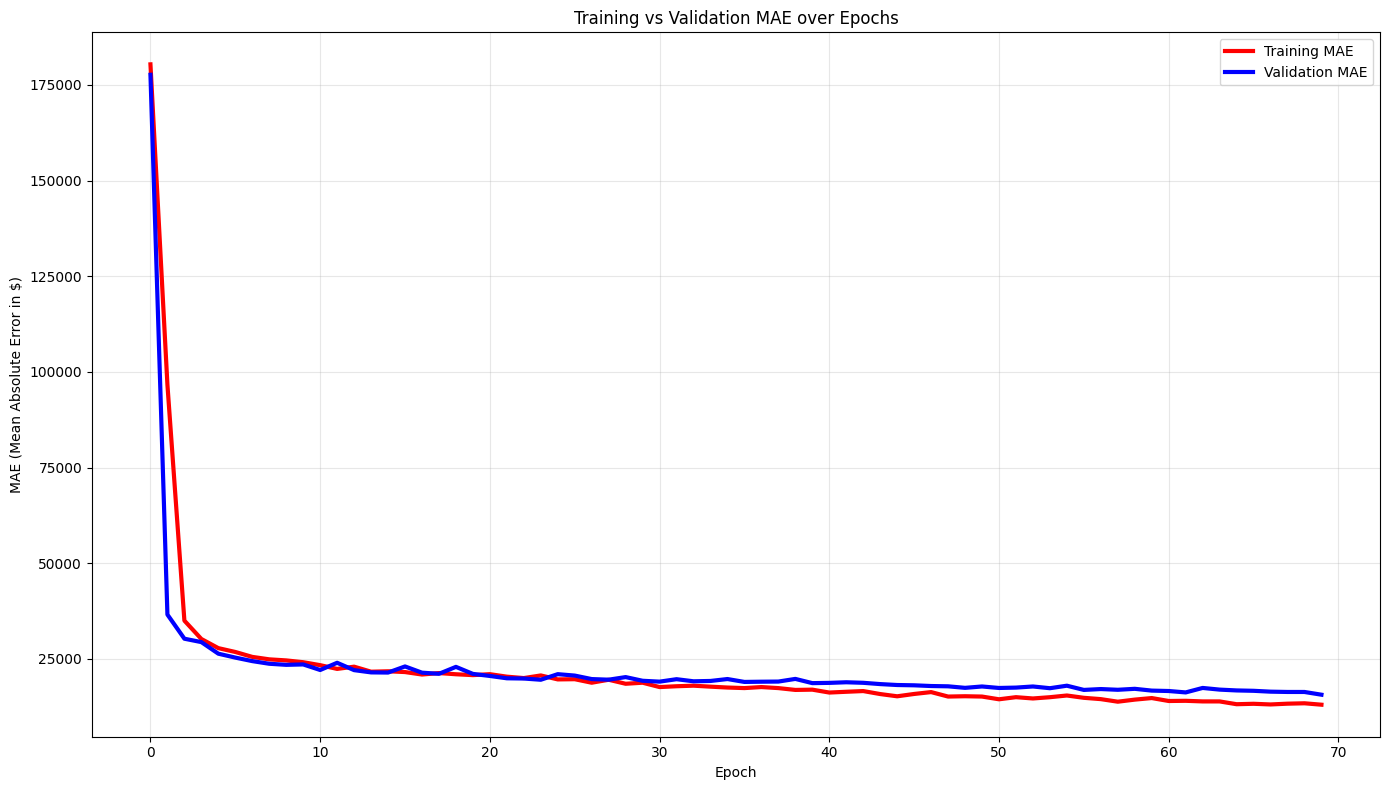

In [25]:
hist_df = pd.DataFrame(history.history)
hist_df['epoch'] = history.epoch
n_epochs = hist_df.shape[0]

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(np.arange(0, n_epochs), hist_df['mae'],     label='Training MAE',   lw=3, color='red')
ax.plot(np.arange(0, n_epochs), hist_df['val_mae'], label='Validation MAE', lw=3, color='blue')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (Mean Absolute Error in $)')
ax.set_title('Training vs Validation MAE over Epochs')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Évaluation sur les données de test

In [30]:
# Vérification des performances du modèle sur l'ensemble de test
test_loss, test_mae = model.evaluate(test, test_target, verbose=0)
print(f"\nTest MSE : {test_loss:,.2f}")
print(f"Test MAE : ${test_mae:,.2f}")
print(f"→ On average the model is off by ${test_mae:,.0f} on house price predictions.")



Test MSE : inf
Test MAE : $681,651,188,062,427,807,744.00
→ On average the model is off by $681,651,188,062,427,807,744 on house price predictions.


In [31]:
# Tester le modèle sur une maison particulière pour voir la précision
sample     = test.iloc[[10]]
prediction = model.predict(sample).squeeze()
actual     = test_target.iloc[10]

print("\nPrediction example:")
print("  Model prediction : ${:,.2f}".format(prediction))
print("  Actual price     : ${:,.2f}".format(actual))
print("  Difference       : ${:,.2f}".format(abs(prediction - actual)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

Prediction example:
  Model prediction : $290,705.84
  Actual price     : $259,000.00
  Difference       : $31,705.84


19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


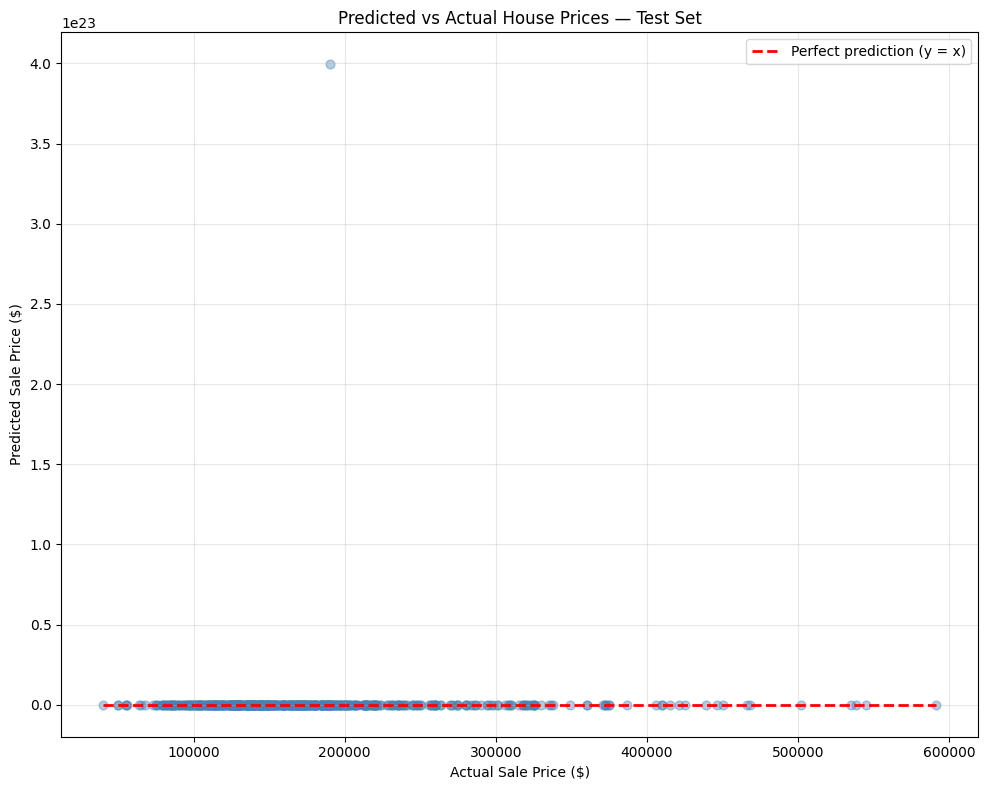

In [32]:
# Visualisation : comparaison des prix réels et prédits pour toutes les maisons de test
all_predictions = model.predict(test).squeeze()

plt.figure(figsize=(10, 8))
plt.scatter(test_target, all_predictions, alpha=0.4, color='steelblue', s=40)
plt.plot([test_target.min(), test_target.max()],
         [test_target.min(), test_target.max()],
         color='red', lw=2, linestyle='--', label='Perfect prediction (y = x)')
plt.xlabel('Actual Sale Price ($)')
plt.ylabel('Predicted Sale Price ($)')
plt.title('Predicted vs Actual House Prices — Test Set')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()